In [1]:
import os
import numpy as np
import xarray as xr
import scipy.integrate as integrate
import scipy.optimize as optimize
import scipy.linalg as linalg

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

import diagnostic_routines as diag

from IPython.display import Image

plt.rcParams['figure.figsize'] = (12,7)

%matplotlib inline

## Set path and file info for the simulation(s)

In [81]:
## set parent directory path for a set of simulations
DIR = '../'
if DIR[-1] != '/': DIR + '/'

## set simulation case subdirectories of DIR; i.e. simulations are in DIR+case 
cases = ['RUN_NAME/']
for i in range(len(cases)):
    assert os.path.isdir(DIR+cases[i]), 'Given simulation directory %s does not exist.'%(os.getcwd()+'/'+DIR+cases[i])
    if cases[i][-1] != '/': cases[i] += '/'

## set name of raw logfile for the simulation
logfile = 'out.txt'

## set iteration numbers for cross sections/energy diagnostics (corresponding to stamp in q.##########.dat etc files)
it_range = [1,3,5,7,9] #list(range(1,11,3))

## Set domain parameters

In [59]:
## Manually set parameters or point to file to scrape parameters

Htot = 4.8e3

nx = int((3*256)/2)
ny = int((3*256)/2)

Lx = 1.3824e6
Ly = 1.3824e6

x = np.arange(nx)/nx*Lx

## Plot timesteps

Text(0.5, 0, 'Iteration [#]')

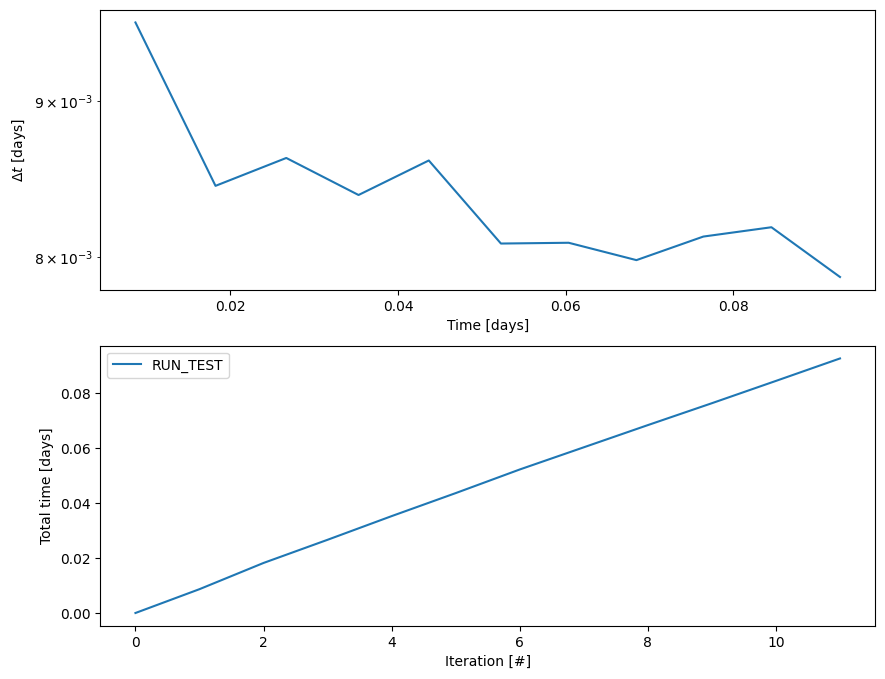

In [60]:
fig, ax = plt.subplots(2,1,figsize=(10,8))

for case in cases:
    time, tstep = diag.get_timesteps(DIR+case,logfile=logfile)

    label = case.split('/')[-2]
    ax[0].semilogy(time,np.array(tstep)/86400.,label=label)
    # ax[0].semilogy(np.cumsum(tstep)/86400.,np.array(tstep)/86400.,label=label)
    ax[1].plot(time,label=label)
    
ax[1].legend()
ax[0].set_ylabel(r'$\Delta t$ [days]')
ax[0].set_xlabel(r'Time [days]')
ax[1].set_ylabel(r'Total time [days]')
ax[1].set_xlabel('Iteration [#]')

## Load select datasets

In [61]:
dss = {}
for case in cases:
    dss[case] = []
    # label = case.split('/')[-2]
    
    for it in it_range:
        ds = diag.get_output(DIR+case,it,Htot,x,x).expand_dims(dim='Time',axis=0)

        ## add output in modal basis if desired and output from the run (e.g. q_mode.000000000.dat)
        dsm = diag.get_modal_output(DIR+case,it,x,x,len(ds.zc),logfile=logfile).expand_dims(dim='Time',axis=0)
        ds = xr.merge([ds,dsm])
        
        dss[case].append(ds)

    if len(it_range) > 1: dss[case] = xr.concat(dss[case],dim='Time')
    else: dss[case] = dss[case][0]
    dss[case] = diag.add_prof_vars(DIR+case,dss[case],Htot)
    
    time, _ = diag.get_timesteps(DIR+case,logfile=logfile)
    dss[case] = dss[case].assign_coords({'Time':[time[i] for i in it_range]}) ## assigning time coordinates assumes out.txt logs every iteration
    

## Plot cross sections

### Time series of horizontal cross sections

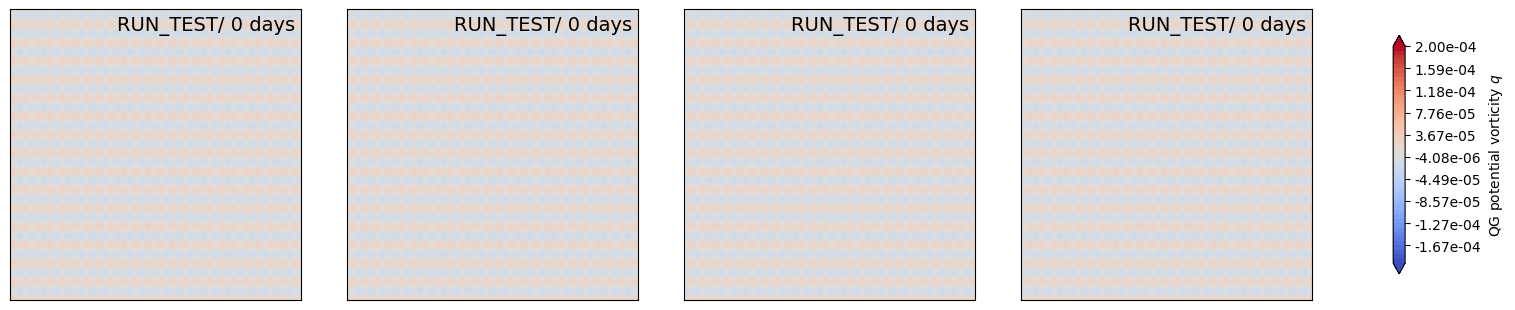

In [62]:
for case in cases:
    
    ncols = 4
    nrows = int((len(it_range)+3)/4.)
    
    fig, ax = plt.subplots(nrows,ncols,figsize=(ncols*4+1,4*nrows))
    plt.tight_layout()
    ax = ax.flatten()
    
    for it in range(len(it_range)):
    
        ds = dss[case]

#         lv = 0                                 ##    set xsec level index or target depth
        lv = np.argmin(np.abs(ds.zc.values+200)) ## or set level target depth [meters]
    
        clevs = np.linspace(-2e-4,2e-4,50)       ## set contour levels/range
        
        X, Y = np.meshgrid(ds.x.values,ds.x.values)
        CS = ax[it].contourf(X,Y, ds.q.values[it,lv,:,:],cmap=plt.cm.coolwarm,levels=clevs,extend='both')
        ax[it].text(0.98,0.98,'%s %.0f days'%(case,ds.Time.values[it]),ha='right',va='top',transform=ax[it].transAxes,fontsize=14)
    
        ax[it].set_aspect('equal')
        ax[it].set_xticks([])
        ax[it].set_yticks([])
        
    for it in range(len(it_range),len(ax)):
        
        ax[it].set_xticks([])
        ax[it].set_yticks([])
        ax[it].axis('off')
    
    
    fig.colorbar(CS,ax=ax,label=r'QG potential vorticity $q$',shrink=0.7,format='%.2e')

### Targeted, combined vertical and horizontal cross sections

Text(0, 0.5, 'Depth [km]')

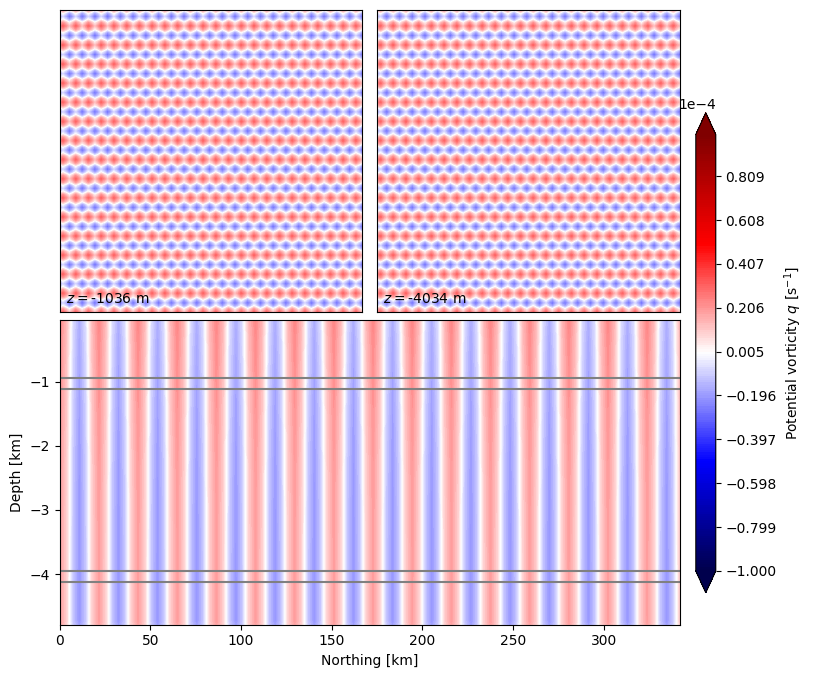

In [63]:
it = 0                                ## set time index
case = cases[0]                       ## set grid / directory
tdepths = [-1000,-4000]               ## set target depths [meters], can be variable number of slices
mag = 1e-4                            ## set scale for contour plot levels
clevs = np.linspace(-mag,mag,200)     ## set contour levels/range 

fig = plt.figure(figsize=(4*len(tdepths),8))
gs = fig.add_gridspec(ncols=len(tdepths), nrows = 2, wspace=0.05,hspace=0.02)

ds = dss[case]

ax = []
for i in range(len(tdepths)):
    ax.append(fig.add_subplot(gs[0, i]))

ax.append(fig.add_subplot(gs[1, :]))

levels = []
X,Y = np.meshgrid(x/1e3,x/1e3)
for axis, tdepth in zip(ax[:-1], tdepths):
    lv = np.argmin(np.abs(ds.zc.values-tdepth))
    levels.append(lv)
    cs = axis.contourf(X,Y,ds.q.values[it,lv,:,:],cmap=plt.cm.seismic,levels=clevs,extend='both')

    axis.text(0.02,0.02,r'$z=$'+'%.0f m'%ds.zc.values[lv],va='bottom',ha='left',transform=axis.transAxes)
    axis.set_aspect('equal')

    axis.set_xticks([])
    axis.set_yticks([])

X,Z = np.meshgrid(x/1e3,ds.zc.values/1e3)
dat = ds.q.values[0,:,30,:]

cs = ax[-1].contourf(X,Z,ds.q.values[it,:,:,30],cmap=plt.cm.seismic,levels=clevs,extend='both')
cbaxes = fig.add_axes([0.92, 0.15, 0.025, 0.6])
cbar = fig.colorbar(cs,cax=cbaxes,label='Potential vorticity $q$ [s$^{-1}$]')
cbar.formatter.set_powerlimits((0, 0))

for lv in levels:
    ax[-1].axhline(ds.zi.values[lv]/1e3,color='grey')
    ax[-1].axhline(ds.zi.values[lv+1]/1e3,color='grey')

ax[-1].set_xlabel('Northing [km]')
ax[-1].set_ylabel('Depth [km]')

# plt.savefig('%s_xsecs.pdf'%grid,bbox_inches='tight')

## Compute and plot energies

#### Total energy

$$
TE = -\frac{1}{2}\sum q\psi
$$

#### Kinetic energy

<!-- $$
KE = \frac{1}{2}\int |\nabla \psi |^2 dv = \frac{1}{2}\int |k|^2|\hat\psi|^2 dV
$$

Layer-averaged discrete values -->

$$
\frac{L^2}{2} \sum_{k} h_k|k|^2 |\hat{\boldsymbol{\psi}}|^2
$$

#### Available potential energy

<!-- % $$
% APE = -\frac{1}{2}\int \psi\partial_z\left(\frac{f^2}{N^2}\partial_z\psi\right) dV=\frac{1}{2}\int \frac{f^2}{N^2} \left(\partial_z\psi\right)^2 dV
% $$

% $$
% APE = -\frac{1}{2}\iint \psi L \psi dA dz \approx -\frac{1}{2} \sum_m \int \psi L \psi dA h_m
% $$

$$
APE = -\frac{1}{2}\iint \psi L \psi dA dz \approx -\frac{1}{2} \sum_m \int \psi L \psi dA h_m
$$ -->

$$
APE = -\frac{L^2}{2} \sum \boldsymbol{\psi}^T H L \boldsymbol{\psi}
$$

In [64]:
for case in cases:
    
    TE = []
    KE = []
    APE = []
    for it in range(len(dss[case].Time)):
    
        ds = dss[case].isel(Time=it)
    
        TE.append(diag.get_TE(ds.p.values,ds.q.values,ds.h.values,Lx,Ly))
        KE.append(diag.get_KE(ds.p.values,Lx,Ly))
        APE.append(diag.get_APE(ds.p.values,ds.h.values,ds.S.values,Lx,Ly))
        
    TE = np.array(TE)
    KE = np.array(KE)
    APE = np.array(APE)
        
    dss[case]['KE_layer_avg'] = xr.DataArray(np.array(KE),dims=['Time','zc'])
    
    dss[case]['TE'] = xr.DataArray(TE,dims=['Time'])
    dss[case]['KE'] = xr.DataArray(np.sum(KE*dss[case].h.values,axis=1),dims=['Time'])
    dss[case]['APE'] = xr.DataArray(APE,dims=['Time'])
    

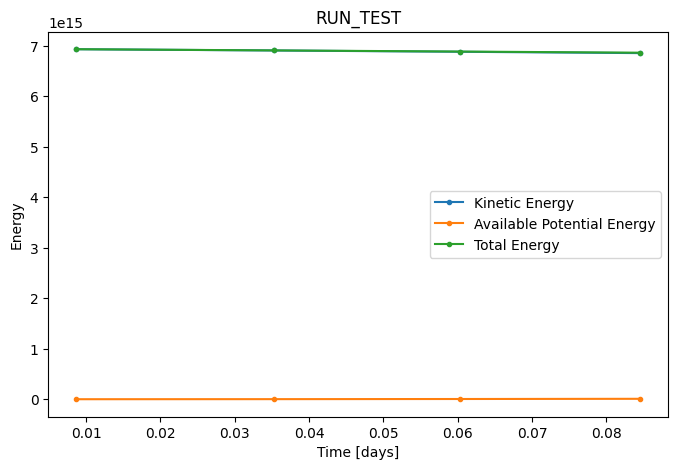

In [77]:
for case in cases:

    fig, ax = plt.subplots(1,1,figsize=(8,5),sharex=True)
    
    ds = dss[case]
    label = case.split('/')[-2]
    
    ax.plot(ds.Time,ds.KE,marker='.',label='Kinetic Energy')    
    ax.plot(ds.Time,ds.APE,marker='.',label='Available Potential Energy')
    ax.plot(ds.Time,ds.TE,marker='.',label='Total Energy')
    
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    ax.set_ylabel('Energy')
    ax.set_xlabel('Time [days]')
    ax.set_title(label)
    
    ax.legend()

## Energy spectra

### Horizontal KE spectrum

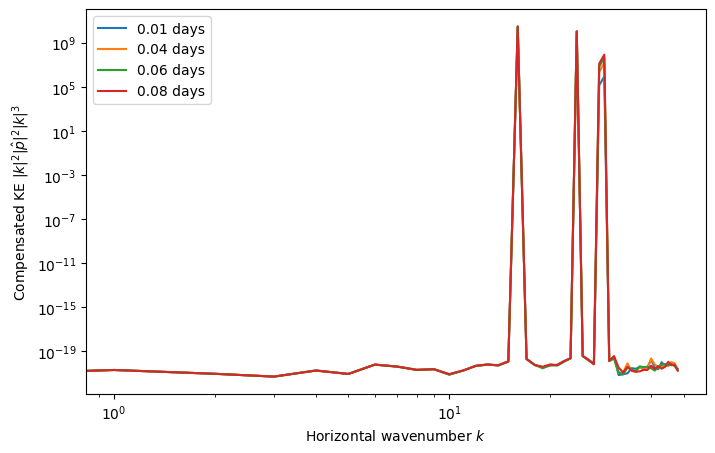

In [67]:
for case in cases:
    plt.figure(figsize=(8,5))
    label = case.split('/')[-2]
    
    for it in range(len(it_range)):

#       lv = 0                                   ##    set xsec level index or target depth
        lv = np.argmin(np.abs(ds.zc.values+200)) ## or set level target depth [meters]
    
        ds = dss[case]
        
        KE_hspec = diag.cospectrum(ds.p.values[it,lv,:,:],ds.p.values[it,lv,:,:])
        ks = np.arange(len(KE_hspec))
        
        plt.loglog(ks,KE_hspec*ks**2*ks**3,label='%.2f days'%ds.Time.values[it])

    plt.title(label)
    plt.legend()
    plt.xlabel('Horizontal wavenumber $k$')
    plt.ylabel(r'Compensated KE $|k|^2|\hat{p}|^2|k|^3$')

### Vertical KE spectrum -- requires modal output

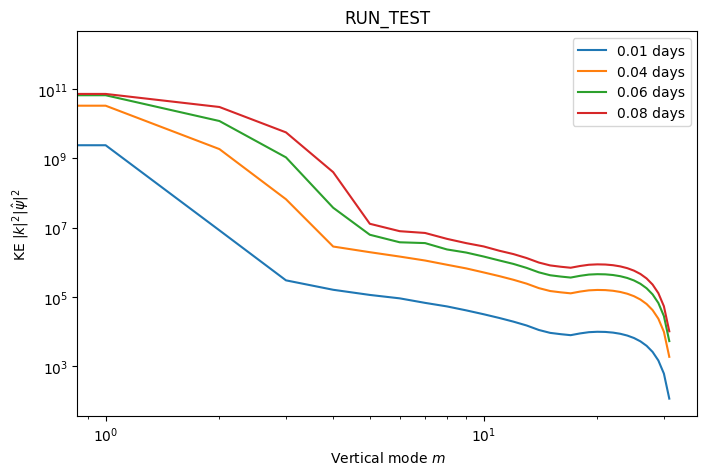

In [78]:
for case in cases:
    plt.figure(figsize=(8,5))
    label = case.split('/')[-2]
    
    for it in range(len(it_range)):
    
#       lv = 0                                   ##    set xsec level index or target depth
        lv = np.argmin(np.abs(ds.zc.values+200)) ## or set level target depth [meters]
    
        ds = dss[case]
        
        KE_vspec = diag.get_KE(ds.pmode.values[it,:,:,:])
        
        plt.loglog(KE_vspec,label='%.2f days'%ds.Time.values[it])

    plt.title(label)
    plt.legend()
    plt.xlabel('Vertical mode $m$')
    plt.ylabel(r'KE $|k|^2|\hat{\psi}|^2$')

In [69]:
TEspec = {}
for case in cases:
    
    TEspec[case] = []
    for it in range(len(dss[case].Time)):
        
        ds = dss[case].isel(Time=it)
        
        TEspec[case].append(diag.get_TE_spectra(ds.pmode.values,ds.qmode.values))
    

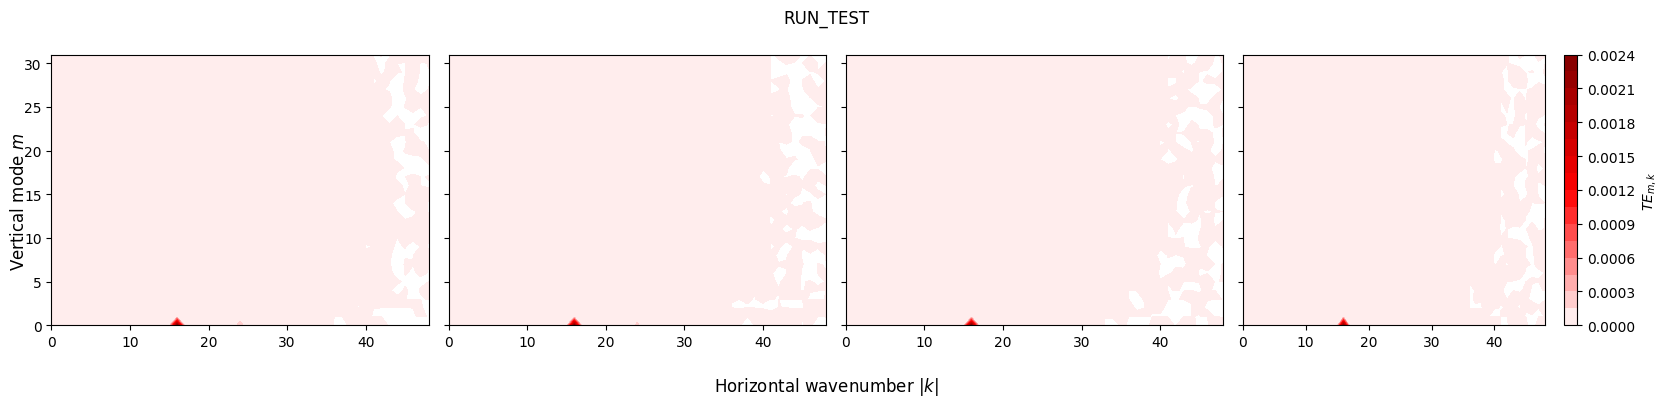

In [80]:
for case in cases:
    
    ncols = 4
    nrows = int((len(it_range)+3)/4.)
    
    fig, ax = plt.subplots(nrows,ncols,figsize=(ncols*4+1,4*nrows),sharex=True,sharey=True)
    plt.tight_layout()
    ax = ax.flatten()
    label = case.split('/')[-2]
    
    for it in range(len(it_range)):
        
        # cs = ax[it].contourf(np.log(TEspec[case][it]),norm=mcolors.CenteredNorm(),cmap=plt.cm.seismic,levels=20)
        cs = ax[it].contourf(TEspec[case][it],norm=mcolors.CenteredNorm(),cmap=plt.cm.seismic,levels=20)

        
    fig.colorbar(cs,label=r'$TE_{m,k}$')
    # fig.colorbar(cs,label=r'$\log(TE_{m,k})$')
    
    fig.supxlabel('Horizontal wavenumber $|k|$')
    fig.supylabel('Vertical mode $m$')
    fig.suptitle(label)
    plt.tight_layout()